# Bayesian Polarimetry: Calibrating a Dual-Rotating-Retarder Polarimeter
_written by Jaren N. Ashcraft_

A **dual-rotating-retarder (DRRP) Mueller polarimeter** measures the full Mueller matrix of a sample by placing it between two rotating retarders, sandwiched by a fixed generator polarizer and a fixed analyzer polarizer:

$$\text{source} \;\rightarrow\; \underbrace{P_{1}}_{\text{generator}} \;\rightarrow\; \underbrace{R_{1}(\theta)}_{\text{rotates } 1\times} \;\rightarrow\; [\text{sample}] \;\rightarrow\; \underbrace{R_{2}(5\theta)}_{\text{rotates } 5\times} \;\rightarrow\; \underbrace{P_{2}}_{\text{analyzer}} \;\rightarrow\; \text{detector}$$

The two retarders are stepped in a fixed $1\!:\!5$ ratio, which spreads the sample's Mueller elements across distinct harmonics of the modulation curve.

Before you can trust such an instrument you have to **calibrate it**: the retarders are never exactly quarter-wave, and every component is mounted with a small unknown angular offset. Here we calibrate the bare instrument (no sample) by measuring its response to an unpolarized source.

There is a subtlety in *which* angles we can hope to recover. The detected power is the top-left Mueller element $M_{00}$, and $M_{00}$ is **invariant under a rigid rotation of the entire instrument** — spin the generator, both retarders, and the analyzer together by any angle $\phi$ and the modulation curve is unchanged. So the four transmission/mounting angles are only defined *relative to a reference*; taken all together they contain one flat, unmeasurable direction. We remove it by **holding the generator polarizer fixed** ($p_1 \equiv 0$), which nails the lab reference frame, and infer the remaining **five** parameters:

| symbol | meaning |
| --- | --- |
| $p_2$ | transmission-axis angle of the analyzer polarizer |
| $\delta_1,\,\delta_2$ | retardances of retarder 1 / 2 |
| $\theta_1,\,\theta_2$ | mounting (start-angle) offsets of retarder 1 / 2 |

($p_1$, the generator transmission axis, is held at $0$ and *defines* the reference — it is not fit.)

We take a **Bayesian** view: rather than a single best-fit, we want the full posterior over these five parameters. We will (1) find the maximum-a-posteriori (MAP) point with `optax`, (2) sample the posterior with `blackjax` NUTS, and (3) compute the **Fisher information matrix** at the MAP as a fast Gaussian (Laplace) approximation — then check that the two agree.

In [1]:
import os

from katsu.katsu_math import np, set_backend_to_jax
set_backend_to_jax()  # must happen before we build any models

import jax
import optax
import zodiax as zdx
import equinox as eqx
import blackjax
from blackjax.progress_bar import progress_bar_scan
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

from katsu.models import Model, LinearDiattenuator, MuellerMatrix
from katsu.mueller import linear_retarder

## A rotating-retarder element

`katsu`'s `LinearRetarder` stores its `fast_axis` directly, but in a DRRP the fast axis at each measurement state is `start_angle + rotation`, where the `rotation` is *commanded* (read off the rotation-stage encoders and therefore known) and the scalar `start_angle` is the unknown mounting offset we want to fit.

We capture exactly that with a small custom `MuellerMatrix`. Only the scalar physical parameters (`start_angle`, `retardance`) are leaves we will differentiate; the `rotation` array rides along as fixed data, and the Mueller matrix is rebuilt from the current parameters every time it is accessed.

In [2]:
class RotatingRetarder(MuellerMatrix):
    """Linear retarder whose fast axis is ``start_angle + rotation``.

    ``rotation`` is the known commanded fast-axis angle at every measurement
    state; ``start_angle`` is the unknown scalar mounting offset to calibrate.
    """

    start_angle: float
    retardance: float
    rotation: np.ndarray
    shape: tuple

    def __init__(self, start_angle, retardance, rotation):
        self.start_angle = start_angle
        self.retardance = retardance
        self.rotation = rotation
        self.shape = rotation.shape

    @property
    def matrix(self):
        return linear_retarder(
            self.start_angle + self.rotation, self.retardance, shape=self.shape
        )

## Building the polarimeter as a `Model`

We assemble the four optics into a `Model`. The first layer in the list is the first optic the light meets, so the system Mueller matrix is $M = P_2\,R_2\,R_1\,P_1$. The polarizers are ideal (`Tmin = 0`); the generator's transmission axis is held at $0$ (our reference), and we fit the analyzer's. Retarder 2 rotates at $5\times$ the rate of retarder 1.

In [3]:
N = 64
theta = np.linspace(0, np.pi, N)  # commanded rotation of retarder 1


def drrp_model(p_gen, delta1, theta1, delta2, theta2, p_ana):
    """Assemble a dual-rotating-retarder polarimeter (light meets layer 0 first)."""
    return Model([
        ("pol_gen", LinearDiattenuator(p_gen, 0.0)),          # generator polarizer
        ("ret1", RotatingRetarder(theta1, delta1, theta)),  # retarder 1, rotates 1x
        ("ret2", RotatingRetarder(theta2, delta2, 5 * theta)),  # retarder 2, rotates 5x
        ("pol_ana", LinearDiattenuator(p_ana, 0.0)),          # analyzer polarizer
    ])


# Nominal "design" instrument: horizontal polarizers and perfect quarter waves.
system = drrp_model(
    np.array(0.0), np.array(np.pi / 2), np.array(0.0),
    np.array(np.pi / 2), np.array(0.0), np.array(0.0),
)

## Simulating a measurement

A real instrument is slightly off-design. We pick a "truth" set of parameters (the analyzer mounted a couple of degrees off horizontal, retardances a few degrees away from quarter-wave, small retarder offsets) and simulate the detected power as the unpolarized source is modulated by the rotating retarders. The generator polarizer stays at $0$ — it defines the reference frame, so its "true" angle is fixed by convention rather than measured. The observed intensity is the top-left element of the system Mueller matrix at each rotation state. Then we add Gaussian read noise.

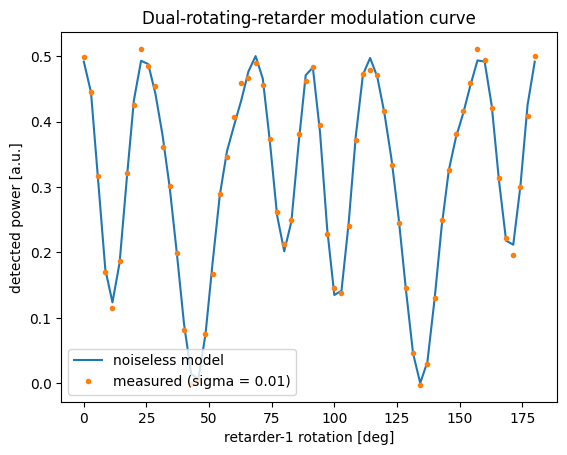

In [4]:
stokes = np.array([1.0, 0.0, 0.0, 0.0])  # unpolarized input

# The real, slightly imperfect instrument -- what we want to recover.
truth = {
    "ret1.retardance": np.radians(95.0),
    "ret1.start_angle": np.radians(3.0),
    "ret2.retardance": np.radians(88.0),
    "ret2.start_angle": np.radians(-4.0),
    "pol_ana.transmission_axis": np.radians(-3.0),
}

truth_power = system.set(truth).forward(stokes)[..., 0]

# Add measurement noise
sigma = 0.01
key = jax.random.PRNGKey(1)
key, noise_key = jax.random.split(key)
data = truth_power + sigma * jax.random.normal(noise_key, truth_power.shape)

plt.figure()
plt.plot(np.degrees(theta), truth_power, label="noiseless model")
plt.plot(np.degrees(theta), data, ".", label=f"measured (sigma = {sigma})")
plt.xlabel("retarder-1 rotation [deg]")
plt.ylabel("detected power [a.u.]")
plt.title("Dual-rotating-retarder modulation curve")
plt.legend()
plt.show()

## The log-posterior

Our model is a Gaussian likelihood (intensities scattered around the model by `sigma`) times **weakly-informative priors** over the five free parameters. The priors are centred on the *design* instrument — the analyzer horizontal, quarter-wave retarders, zero offsets — with a width of $0.2\,\mathrm{rad}\approx11^\circ$. That says "the instrument is built close to its design, but we allow it to move," and it conveniently selects a single mode (a retarder's fast axis is only defined mod $\pi$, and $\delta \leftrightarrow -\delta$ flips handedness, so the unconstrained problem is multi-modal). With the generator polarizer already pinned as the reference, the global-rotation flat direction is gone, so the priors only have to resolve these discrete ambiguities rather than a continuous one.

In [5]:
# Priors centred on the design instrument
prior_mu = {
    "pol_ana.transmission_axis": 0.0,
    "ret1.retardance": np.pi / 2,
    "ret2.retardance": np.pi / 2,
    "ret1.start_angle": 0.0,
    "ret2.start_angle": 0.0,
}
prior_sigma = 0.2  # ~11 deg


def log_posterior(theta):
    observed = system.set(theta).forward(stokes)[..., 0]
    log_like = -0.5 * np.sum(((observed - data) / sigma) ** 2)
    log_prior = sum(
        -0.5 * ((theta[k] - prior_mu[k]) / prior_sigma) ** 2 for k in theta
    )
    return log_like + log_prior


# The optimiser and the Fisher matrix work with the negative log-posterior.
neg_log_post = lambda theta: -1.0 * log_posterior(theta)

## Step 1 — the MAP estimate

We first descend the negative log-posterior with Adam, starting from the design instrument. This point estimate doubles as (a) the starting point for the sampler and (b) the expansion point for the Fisher matrix.

In [6]:
# Start from the design instrument
params = {k: np.array(v) for k, v in prior_mu.items()}

optimizers = {k: optax.adam(1e-2) for k in params}
optim, state = zdx.optimisation.map_optimisers(params, optimizers)

loss_grad = eqx.filter_jit(eqx.filter_value_and_grad(neg_log_post))

losses = []
for step in tqdm(range(2000)):
    loss, grads = loss_grad(params)
    updates, state = optim.update(grads, state)
    params = optax.apply_updates(params, updates)
    losses.append(loss)

print("MAP estimate vs truth (degrees):")
for k in sorted(params):
    print(f"  {k:28s}  MAP={float(np.degrees(params[k])):+8.3f}"
          f"   truth={float(np.degrees(truth[k])):+8.3f}")

100%|██████████| 2000/2000 [00:05<00:00, 356.02it/s]

MAP estimate vs truth (degrees):
  pol_ana.transmission_axis     MAP=  -3.991   truth=  -3.000
  ret1.retardance               MAP= +95.406   truth= +95.000
  ret1.start_angle              MAP=  +2.744   truth=  +3.000
  ret2.retardance               MAP= +87.310   truth= +88.000
  ret2.start_angle              MAP=  -4.810   truth=  -4.000


## Step 2 — sampling the posterior with NUTS

Now the Bayesian part. We hand the same `log_posterior` to `blackjax`'s No-U-Turn Sampler, let `window_adaptation` tune the step size and mass matrix, and start the chain at the MAP. `progress_bar_scan` gives us a tqdm bar from inside the compiled `lax.scan`.

In [7]:
key, warmup_key = jax.random.split(key)
warmup = blackjax.window_adaptation(
    blackjax.nuts, log_posterior, target_acceptance_rate=0.8
)
(last_state, tuned), _ = warmup.run(warmup_key, params, num_steps=500)

nuts = blackjax.nuts(log_posterior, **tuned)


def inference_loop(key, initial_state, num_samples):
    @progress_bar_scan(num_samples)
    def one_step(state, xs):
        _, k = xs
        state, info = nuts.step(k, state)
        return state, (state.position, info.is_divergent)

    keys = jax.random.split(key, num_samples)
    xs = (np.arange(num_samples), keys)
    _, (positions, divergent) = jax.lax.scan(one_step, (initial_state, -1), xs)
    return positions, divergent


key, sample_key = jax.random.split(key)
samples, divergent = inference_loop(sample_key, last_state, 4000)
print(f"drew {divergent.shape[0]} samples with {int(np.sum(divergent))} divergences")

<div><progress max="4000" value="4000"></progress> 100.00% [4000/4000 00:00&lt;?]</div>

drew 4000 samples with 0 divergences


## Step 3 — the Fisher information matrix at the MAP

The Hessian of the negative log-posterior at the MAP *is* the Fisher information matrix $\mathbf{F}$ under the Laplace approximation, and its inverse is the parameter covariance $\mathbf{C} = \mathbf{F}^{-1}$. `zodiax` gives us a batched Hessian. This is far cheaper than MCMC — a single Hessian evaluation — so it is worth checking how well it reproduces the sampled spreads.

In [8]:
# Fisher information = Hessian of the negative log-posterior at the MAP.
fim, unflatten = zdx.hessian(neg_log_post, params, nbatches=1)
cov = jax.device_get(np.linalg.inv(fim))

# jax flattens dict leaves in sorted-key order.
order = sorted(params)
print(f"{'parameter':28s}  Fisher 1-sigma [deg]   NUTS 1-sigma [deg]")
for i, k in enumerate(order):
    fisher_sd = float(np.degrees(np.sqrt(cov[i, i])))
    nuts_sd = float(np.degrees(np.std(samples[k])))
    print(f"  {k:26s}  {fisher_sd:10.3f}        {nuts_sd:14.3f}")

parameter                     Fisher 1-sigma [deg]   NUTS 1-sigma [deg]
  pol_ana.transmission_axis        0.680                 0.668
  ret1.retardance                  0.728                 0.699
  ret1.start_angle                 0.255                 0.254
  ret2.retardance                  0.746                 0.745
  ret2.start_angle                 0.601                 0.593


## The corner plot

Finally we overlay the two posteriors: the NUTS samples and the Fisher/Laplace Gaussian built straight from the covariance with `Chain.from_covariance`. Dashed lines mark the true parameters. The Gaussian approximation sits right on top of the full posterior — for a fraction of the cost — and both bracket the truth.

The correlation structure tells the calibration story. The dominant degeneracy is now **analyzer-side**: $p_2$ and $\theta_2$ are tied together at $\rho \approx 0.93$ (rotating the analyzer looks almost exactly like rotating the retarder next to it), so those two are the widest of the angular parameters ($\sim\!0.6$–$0.7^\circ$). Because we fixed the generator polarizer, retarder 1 no longer has an adjacent free polarizer to trade against, and $\theta_1$ becomes the **best-constrained** parameter of all ($\sim\!0.25^\circ$) — though it still leans on the analyzer pair through weaker $\sim\!0.6$ correlations. The retardances $\delta_1,\delta_2$ are the mirror image: essentially **uncorrelated** with the mounting angles ($|\rho|\lesssim0.16$), but the *loosest* parameters here ($\sim\!0.73$–$0.75^\circ$), since $M_{00}$ constrains a near-quarter-wave retardance only weakly.

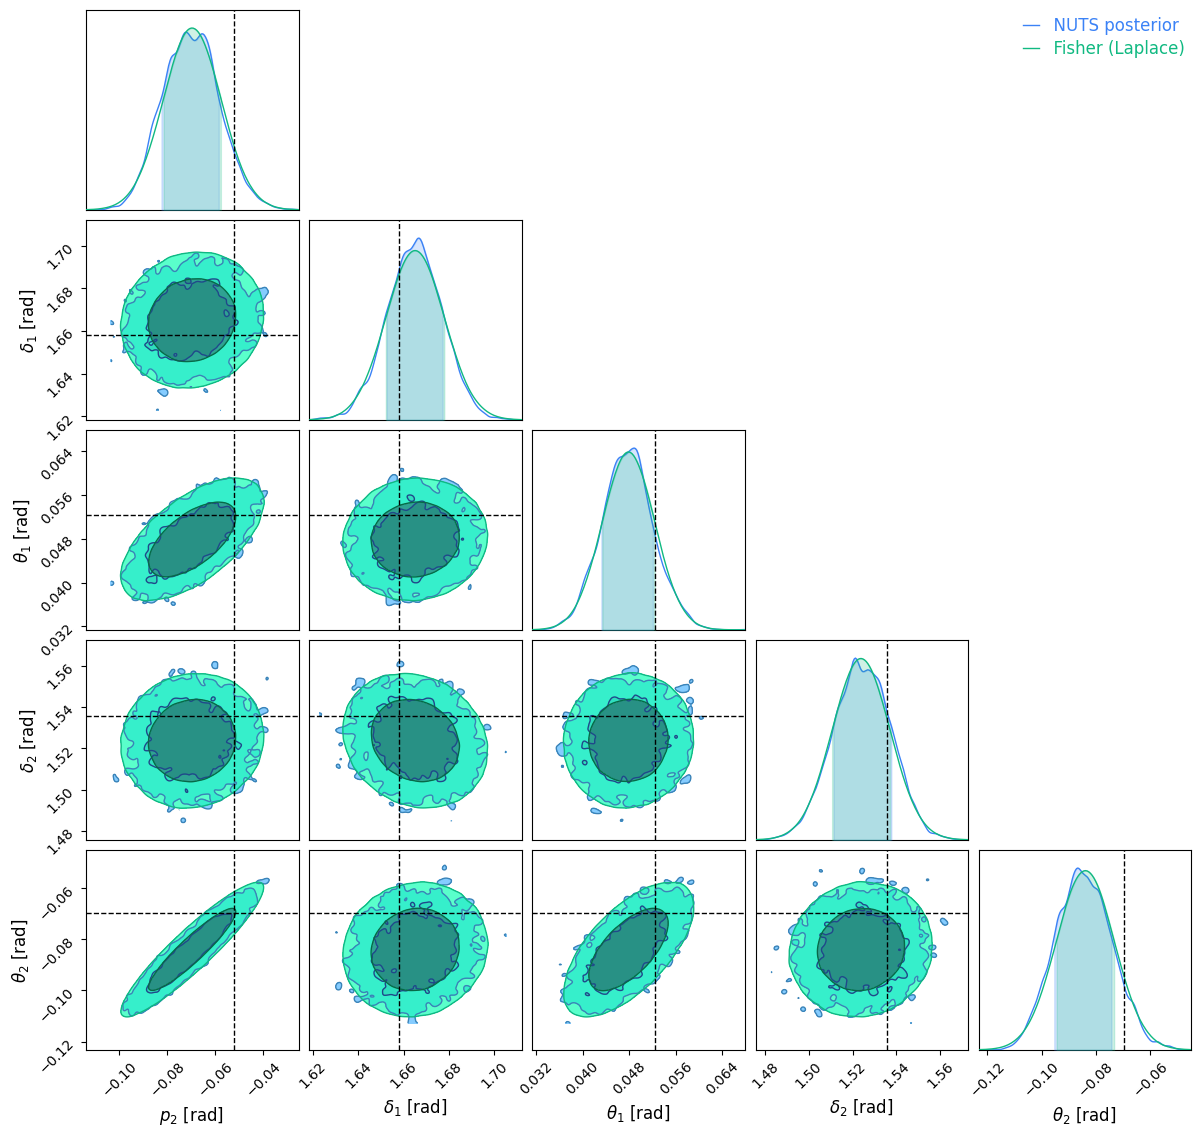

In [9]:
from chainconsumer import ChainConsumer, Chain, Truth

labels = {
    "pol_gen.transmission_axis": r"$p_1$ [rad]",
    "ret1.retardance": r"$\delta_1$ [rad]",
    "ret1.start_angle": r"$\theta_1$ [rad]",
    "ret2.retardance": r"$\delta_2$ [rad]",
    "ret2.start_angle": r"$\theta_2$ [rad]",
    "pol_ana.transmission_axis": r"$p_2$ [rad]",
}
order = sorted(params)
columns = [labels[k] for k in order]

posterior = pd.DataFrame({labels[k]: jax.device_get(samples[k]) for k in order})

cc = ChainConsumer()
cc.add_chain(Chain(samples=posterior, name="NUTS posterior"))
cc.add_chain(Chain.from_covariance(
    [float(params[k]) for k in order], cov, columns=columns, name="Fisher (Laplace)"
))
cc.add_truth(Truth(location={labels[k]: float(truth[k]) for k in order}))

cc.plotter.plot()
plt.show()

## Takeaways

- A DRRP polarimeter is naturally expressed as a `Model` once we add a small `RotatingRetarder` element that separates the *known* commanded rotation from the *unknown* mounting offset.
- The detected power $M_{00}$ is invariant under a rigid rotation of the whole instrument, so not all four angles are identifiable. Fixing the generator polarizer as the reference frame removes that flat direction and leaves a well-posed **five**-parameter problem.
- All five instrument parameters are recovered from a single noisy air measurement, and the NUTS posterior and the Fisher/Laplace approximation agree closely.
- The corner plot exposes the physics: the analyzer axis $p_2$ and its neighbouring start angle $\theta_2$ are strongly degenerate ($\rho\approx0.93$), while pinning the generator makes the *opposite* retarder offset $\theta_1$ the tightest-constrained parameter. The retardances are cleanly decoupled from the mounting angles but the least tightly constrained — exactly the kind of insight a single point estimate would hide.